# Figure 1
Mathieu Bourdenx - 2026

In [1]:
import os
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as colors
import seaborn as sns
import anndata as ad
from adjustText import adjust_text
import statsmodels.formula.api as smf
from scipy.stats import ttest_ind, ttest_rel
from matplotlib_venn import venn2

# Custom plotting functions
from src.plot_all_datasets import plot_a_protein

In [2]:
import warnings
warnings.simplefilter('ignore')

## Housekeeping

In [3]:
raw_data_path = '../data/raw_data'
processed_data_path = '../data/processed_data'

figure_path = '../figures/figure1'
os.makedirs(figure_path, exist_ok=True)

In [4]:
# Group colors
group_colors = {'pos': '#FEC200', 
         'neg': '#0C6F9F'}

# Load data

### Full raw dataset

In [5]:
metadata = pd.read_csv(os.path.join(raw_data_path, 'metadata.csv'))
metadata.index = metadata['Sample ID']

In [6]:
intensities = pd.read_csv(os.path.join(raw_data_path, 'ms_intensity.csv'), index_col=0)

In [7]:
full_raw = ad.AnnData(X=intensities, obs=metadata)

### Raw data

In [8]:
pool_raw = ad.read_h5ad(os.path.join(raw_data_path, 'pools_raw.h5ad'))
single_raw = ad.read_h5ad(os.path.join(raw_data_path, 'sc_raw.h5ad'))

### Processed

In [9]:
pool = ad.read_h5ad(os.path.join(processed_data_path, 'pool_processed.h5ad'))
single = ad.read_h5ad(os.path.join(processed_data_path, 'sc_processed.h5ad'))

# Figure 1b - Number of proteins

In [10]:
nprot = (~np.isnan(pool_raw.X)).sum(axis=1)
nprot_pool = pd.DataFrame(nprot, columns=['detected'])
nprot_pool['TauStatus'] = pool_raw.obs['tau_status'].values
nprot_pool['Assay'] = '20x Cells'

In [11]:
nprot = (~np.isnan(single_raw.X)).sum(axis=1)
nprot_sc = pd.DataFrame(nprot, columns=['detected'])
nprot_sc['TauStatus'] = single_raw.obs['tau_status'].values
nprot_sc['Assay'] = '1x Cell'

In [12]:
total = pd.concat([nprot_pool, nprot_sc])

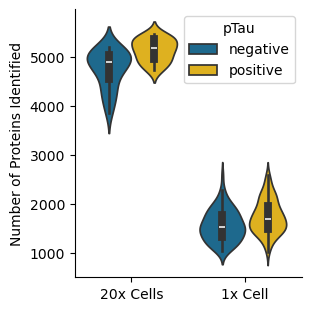

In [13]:
plt.figure(figsize=(3,3), constrained_layout=True)
sns.violinplot(data=total, x='Assay', y='detected', hue='TauStatus', palette=[group_colors['neg'], group_colors['pos']])
sns.despine()
plt.ylabel('Number of Proteins Identified')
plt.legend(title='pTau')
plt.xlabel('')
plt.savefig(os.path.join(figure_path, 'Fig1B_nprot.png'), dpi=300)
plt.savefig(os.path.join(figure_path, 'Fig1B_nprot.pdf'))
plt.show()

# Figure 1c - Intensity/rank plots combined

In [14]:
mean_int_pool = pd.DataFrame(pool.X.mean(axis=0), columns=['intensity'])
mean_int_pool.index = pool.var['GeneName']
mean_int_pool.sort_values(by='intensity', ascending=False, inplace=True)
mean_int_pool['rank'] = range(mean_int_pool.shape[0])
mean_int_pool['raw_intensity'] = 2 ** mean_int_pool['intensity']

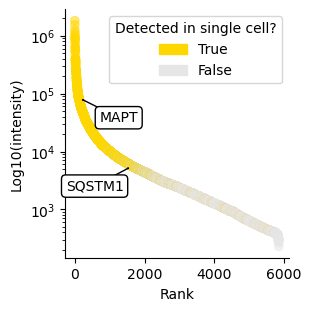

In [15]:
color_mask = ['gold' if i in list(single.var.index) else '.90' for i in mean_int_pool.index] 

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3,3), constrained_layout=True)
ax.scatter(mean_int_pool['rank'], mean_int_pool['raw_intensity'], label='MiniBulk', c=color_mask, alpha=0.5)

ax.set_yscale('log')
# plt.scatter(mean_int_single['rank'], mean_int_single['intensity'], label='SCP', c='teal')
ax.set_ylabel('Log10(intensity)')
ax.set_xlabel('Rank')

legend_handles = [
    mpatches.Patch(color='gold', label='True'),
    mpatches.Patch(color='.90', label='False')
]
ax.legend(handles=legend_handles, loc='upper right', title='Detected in single cell?')

markers = ['MAPT', 'SQSTM1']
props = dict(boxstyle='round', facecolor='white')
texts = [plt.text(mean_int_pool.loc[i, 'rank'], mean_int_pool.loc[i, 'raw_intensity'], i , ha='center', va='center', bbox=props) for i in markers]
adjust_text(texts, expand=(3, 3), arrowprops=dict(arrowstyle='-|>', color='k'), ax=ax)
sns.despine()
fig.savefig(os.path.join(figure_path, 'Fig1C_dynamic_range.png'), dpi=300)
fig.savefig(os.path.join(figure_path, 'Fig1C_dynamic_range.pdf'))

plt.show()

### Insert - Venn

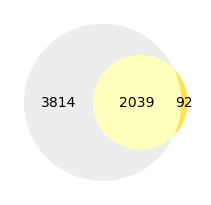

In [16]:
overlap = list(set(pool.var['UniprotName']) & set(single.var['UniprotName']))
unique_pool = list(set(pool.var['UniprotName']) - set(single.var['UniprotName']))
unique_single = list(set(single.var['UniprotName']) - set(pool.var['UniprotName']))


fig,ax = plt.subplots(nrows=1, ncols=1, figsize=(2,2), constrained_layout=True)
venn2([set(pool.var['UniprotName']), set(single.var['UniprotName'])],  set_colors=('.90', 'gold'), set_labels=('', ''), alpha=0.7, ax=ax)
plt.savefig(os.path.join(figure_path, 'Fig1C_venn.png'), dpi=300)
plt.show()

# Figure 1d - Neuronal markers in mini-pools

In [17]:
mean_int_pos = pd.DataFrame(pool[pool.obs['TauStatus'] == 'positive'].X.mean(axis=0), columns=['intensity'])
mean_int_pos.index = pool.var['GeneName']

In [18]:
mean_int_pos['raw_intensity'] = 2 ** mean_int_pos['intensity']
mean_int_pos.sort_values(by='raw_intensity', ascending=False, inplace=True)
mean_int_pos['rank'] = range(mean_int_pos.shape[0])

In [19]:
mean_int_neg = pd.DataFrame(pool[pool.obs['TauStatus'] == 'negative'].X.mean(axis=0), columns=['intensity'])
mean_int_neg.index = pool.var['GeneName']

In [20]:
mean_int_neg['raw_intensity'] = 2 ** mean_int_neg['intensity']  
mean_int_neg.sort_values(by='raw_intensity', ascending=False, inplace=True)
mean_int_neg['rank'] = range(mean_int_neg.shape[0])

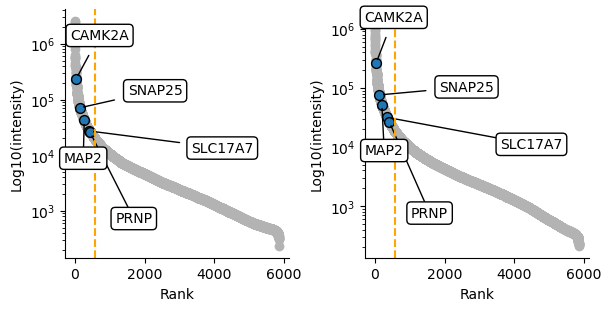

In [21]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6,3), constrained_layout=True)

top10pct = np.percentile(mean_int_neg['rank'], q=10)
ax[0].axvline(x=top10pct, linestyle='dashed', c='orange')

ax[0].scatter(mean_int_neg['rank'], mean_int_neg['raw_intensity'], c='.7')
ax[0].set_yscale('log')
neuronal = ['MAP2', 'SLC17A7', 'CAMK2A', 'SNAP25', 'PRNP']

ax[0].scatter(mean_int_neg.loc[neuronal, 'rank'], mean_int_neg.loc[neuronal, 'raw_intensity'], label='Neuronal markers', edgecolors='k', s=50)

props = dict(boxstyle='round', facecolor='white')
texts = [ax[0].text(mean_int_neg.loc[i, 'rank'], mean_int_neg.loc[i, 'raw_intensity'], i , ha='center', va='center', bbox=props) for i in neuronal]
adjust_text(texts, expand=(3, 4), # expand text bounding boxes by 1.2 fold in x direction and 2 fold in y direction
            arrowprops=dict(arrowstyle='->', color='k'), ax=ax[0] # ensure the labeling is clear by adding arrows
            );

ax[0].set_ylabel('Log10(intensity)')
ax[0].set_xlabel('Rank')

top10pct = np.percentile(mean_int_pos['rank'], q=10)
ax[1].axvline(x=top10pct, linestyle='dashed', c='orange')

ax[1].scatter(mean_int_pos['rank'], mean_int_pos['raw_intensity'], c='.7')
ax[1].set_yscale('log')
neuronal = ['MAP2', 'SLC17A7', 'CAMK2A', 'SNAP25', 'PRNP']

ax[1].scatter(mean_int_pos.loc[neuronal, 'rank'], mean_int_pos.loc[neuronal, 'raw_intensity'], label='Neuronal markers', edgecolors='k', s=50)

props = dict(boxstyle='round', facecolor='white')
texts = [ax[1].text(mean_int_pos.loc[i, 'rank'], mean_int_pos.loc[i, 'raw_intensity'], i , ha='center', va='center', bbox=props) for i in neuronal]
adjust_text(texts, expand=(3, 4), # expand text bounding boxes by 1.2 fold in x direction and 2 fold in y direction
            arrowprops=dict(arrowstyle='->', color='k'), ax=ax[1] # ensure the labeling is clear by adding arrows
            );


ax[1].set_ylabel('Log10(intensity)')
ax[1].set_xlabel('Rank')

sns.despine()

plt.savefig(os.path.join(figure_path, 'Fig1d_neuronal_markers.png'), dpi=300)
plt.savefig(os.path.join(figure_path, 'Fig1d_neuronal_markers.pdf'))

plt.show()

# Figure 1e - Cell type markers in single-cell data

In [22]:
mean_int_pos = pd.DataFrame(single[single.obs['TauStatus'] == 'positive'].X.mean(axis=0), columns=['intensity'])
mean_int_pos.index = single.var['GeneName']

In [23]:
mean_int_pos['raw_intensity'] = 2 ** mean_int_pos['intensity']
mean_int_pos.sort_values(by='raw_intensity', ascending=False, inplace=True)
mean_int_pos['rank'] = range(mean_int_pos.shape[0])

In [24]:
mean_int_neg = pd.DataFrame(single[single.obs['TauStatus'] == 'negative'].X.mean(axis=0), columns=['intensity'])
mean_int_neg.index = single.var['GeneName']

In [25]:
mean_int_neg['raw_intensity'] = 2 ** mean_int_neg['intensity']  
mean_int_neg.sort_values(by='raw_intensity', ascending=False, inplace=True)
mean_int_neg['rank'] = range(mean_int_neg.shape[0])

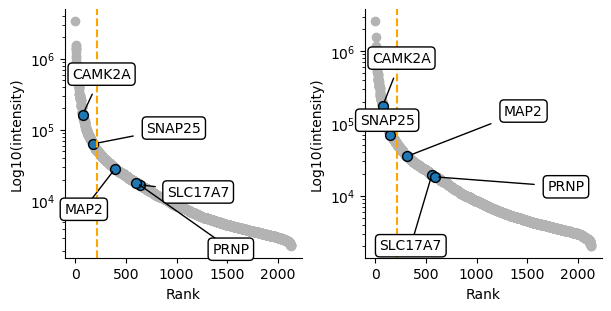

In [26]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6,3), constrained_layout=True)

top10pct = np.percentile(mean_int_neg['rank'], q=10)
ax[0].axvline(x=top10pct, linestyle='dashed', c='orange')

ax[0].scatter(mean_int_neg['rank'], mean_int_neg['raw_intensity'], c='.7')
ax[0].set_yscale('log')
neuronal = ['MAP2', 'SLC17A7', 'CAMK2A', 'SNAP25', 'PRNP']

ax[0].scatter(mean_int_neg.loc[neuronal, 'rank'], mean_int_neg.loc[neuronal, 'raw_intensity'], label='Neuronal markers', edgecolors='k', s=50)

props = dict(boxstyle='round', facecolor='white')
texts = [ax[0].text(mean_int_neg.loc[i, 'rank'], mean_int_neg.loc[i, 'raw_intensity'], i , ha='center', va='center', bbox=props) for i in neuronal]
adjust_text(texts, expand=(3, 4), # expand text bounding boxes by 1.2 fold in x direction and 2 fold in y direction
            arrowprops=dict(arrowstyle='->', color='k'), ax=ax[0] # ensure the labeling is clear by adding arrows
            );

ax[0].set_ylabel('Log10(intensity)')
ax[0].set_xlabel('Rank')

top10pct = np.percentile(mean_int_pos['rank'], q=10)
ax[1].axvline(x=top10pct, linestyle='dashed', c='orange')

ax[1].scatter(mean_int_pos['rank'], mean_int_pos['raw_intensity'], c='.7')
ax[1].set_yscale('log')
neuronal = ['MAP2', 'SLC17A7', 'CAMK2A', 'SNAP25', 'PRNP']

ax[1].scatter(mean_int_pos.loc[neuronal, 'rank'], mean_int_pos.loc[neuronal, 'raw_intensity'], label='Neuronal markers', edgecolors='k', s=50)

props = dict(boxstyle='round', facecolor='white')
texts = [ax[1].text(mean_int_pos.loc[i, 'rank'], mean_int_pos.loc[i, 'raw_intensity'], i , ha='center', va='center', bbox=props) for i in neuronal]
adjust_text(texts, expand=(3, 4), # expand text bounding boxes by 1.2 fold in x direction and 2 fold in y direction
            arrowprops=dict(arrowstyle='->', color='k'), ax=ax[1] # ensure the labeling is clear by adding arrows
            );


ax[1].set_ylabel('Log10(intensity)')
ax[1].set_xlabel('Rank')
sns.despine()

plt.savefig(os.path.join(figure_path, 'Fig1e_sc_neuronal_markers.png'), dpi=300)
plt.savefig(os.path.join(figure_path, 'Fig1e_sc_neuronal_markers.pdf'))

plt.show()

# Figure 1f - EWCE results

In [27]:
# Load EWCE results
ewce = pd.read_csv(os.path.join(processed_data_path, 'EWCE_bluelake_lvl2.csv'))

# Plot horizontal bar plot of ewce 'sd_from_mean' values, sorted alphabetically on 'CellType'
ewce_sorted = ewce.sort_values(by='CellType', ascending=False)
ewce_sorted['sd_from_mean'] = ewce_sorted['sd_from_mean'].astype('float64')

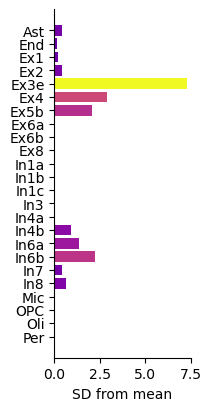

In [28]:
plt.figure(figsize=(2,4), constrained_layout=True)

norm = colors.Normalize(vmin=ewce_sorted['sd_from_mean'].min(), vmax=ewce_sorted['sd_from_mean'].max())
cmap = plt.get_cmap('plasma')
bar_colors = cmap(norm(ewce_sorted['sd_from_mean']))

plt.barh(ewce_sorted['CellType'], ewce_sorted['sd_from_mean'], color=bar_colors)
plt.xlim(0, 7.5)
plt.ylabel('')
plt.xlabel('SD from mean')

sns.despine()

plt.savefig(os.path.join(figure_path, 'Fig1f_ewce_sd_from_mean.png'), dpi=300)
plt.savefig(os.path.join(figure_path, 'Fig1f_ewce_sd_from_mean.pdf'))
plt.show()

# Figure 1g - Tau levels

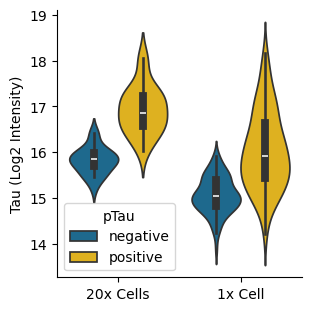

                       sum_sq     df           F        PR(>F)
TauStatus           56.863375    1.0  132.677017  1.776909e-24
Modality            24.312825    1.0   56.728132  1.175514e-12
TauStatus:Modality   0.162033    1.0    0.378064  5.392569e-01
Residual            97.288787  227.0         NaN           NaN
            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1             group2       meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------------
  1x Cell_negative   1x Cell_positive   0.9746    0.0  0.7242  1.225   True
  1x Cell_negative 20x Cells_negative   0.7581    0.0  0.3502  1.166   True
  1x Cell_negative 20x Cells_positive   1.8678    0.0  1.4599 2.2757   True
  1x Cell_positive 20x Cells_negative  -0.2165 0.4926 -0.6132 0.1801  False
  1x Cell_positive 20x Cells_positive   0.8932    0.0  0.4966 1.2899   True
20x Cells_negative 20x Cells_positive   1.1098    0.0  0.5989 1.6206   True
-

In [10]:
plot_a_protein(pool, single, protein_name='MAPT', label_name='Tau', filename='Fig1g_MAPT_levels', figure_path=figure_path)

# Figure 1i - pTau detection

## pTau217

In [41]:
count_positive = pool.obs.groupby(['TauStatus']).apply(
    lambda x: (x['pTau_217'] > 0).sum()
).reset_index(name='count_positive')

count_positive

,TauStatus,count_positive
0,negative,0
1,positive,19


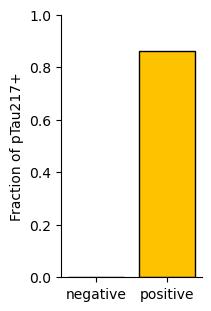

In [44]:
plt.figure(figsize=(2,3), constrained_layout=True)
plt.bar(x=[0,1], height=[0/22,19/22], facecolor=[group_colors['neg'], group_colors['pos']], label='detected', edgecolor='k') 
plt.xticks([0,1], ['negative', 'positive'])
plt.ylim(0,1)
plt.ylabel('Fraction of pTau217+')
sns.despine()
plt.savefig(os.path.join(figure_path, 'Fig1i_frac_detect_p217.png'), dpi=300)

## pTau231

In [45]:
count_positive = pool.obs.groupby(['TauStatus']).apply(
    lambda x: (x['pTau_231'] > 0).sum()
).reset_index(name='count_positive')

count_positive

,TauStatus,count_positive
0,negative,8
1,positive,22


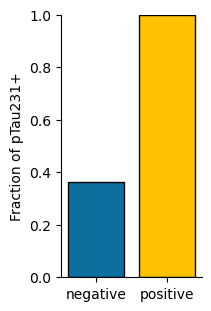

In [51]:
plt.figure(figsize=(2,3), constrained_layout=True)
plt.bar(x=[0,1], height=[8/22,22/22], facecolor=[group_colors['neg'], group_colors['pos']], label='detected', edgecolor='k') 
plt.xticks([0,1], ['negative', 'positive'])
plt.ylabel('Fraction of pTau231+')
plt.ylim(0,1)
sns.despine()
plt.savefig(os.path.join(figure_path, 'Fig1ifrac_detect_p231.png'), dpi=300)

# Figure 1j - Immunofluorescence for pTau217

In [63]:
t217_pct = pd.read_excel(os.path.join(raw_data_path, 'p231 and p217 thresholded final data sheet.xlsx'), sheet_name='p217 %')
t217_pct.dropna(inplace=True)

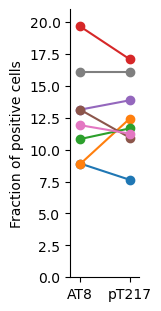

In [64]:
plt.figure(figsize=(1.5,3), constrained_layout=True)

for i in t217_pct.index:
    plt.plot([0,1], [t217_pct.loc[i, '% of at8 positive cells '], t217_pct.loc[i, '% of t231 positive cells ']], 'o-')

sns.despine()
plt.ylabel('Fraction of positive cells')
plt.ylim(0, 21)
plt.xlim(-.2, 1.2)
plt.xticks([0,1], ['AT8', 'pT217'])
plt.savefig(os.path.join(figure_path, 'Fig1j_at8_t217.png'), dpi=300)
plt.show()

In [65]:
ttest_rel(t217_pct['% of at8 positive cells '], t217_pct['% of t231 positive cells '])

TtestResult(statistic=np.float64(0.28404700564959534), pvalue=np.float64(0.7845926774804071), df=np.int64(7))

# Figure 1k - Immunofluorescence for pTau231

In [66]:
t231_pct = pd.read_excel(os.path.join(raw_data_path, 'p231 and p217 thresholded final data sheet.xlsx'), sheet_name='p231 %')

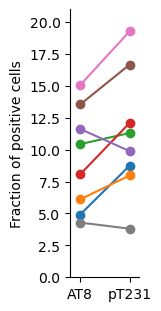

In [67]:
plt.figure(figsize=(1.5,3), constrained_layout=True)

for i in t231_pct.index:
    plt.plot([0,1], [t231_pct.loc[i, '% of at8 positive cells '], t231_pct.loc[i, '% of t231 positive cells ']], 'o-')

sns.despine()
plt.ylabel('Fraction of positive cells')
plt.ylim(0, 21)
plt.xlim(-.2, 1.2)
plt.xticks([0,1], ['AT8', 'pT231'])
plt.savefig(os.path.join(figure_path, 'Fig1k_at8_t231.png'), dpi=300)
plt.show()

In [68]:
ttest_rel(t231_pct['% of at8 positive cells '], t231_pct['% of t231 positive cells '])

TtestResult(statistic=np.float64(-2.483892978825337), pvalue=np.float64(0.041970163467329555), df=np.int64(7))

# Figure 1l - pTau231 levels

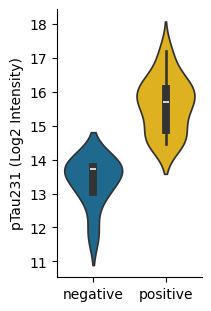

In [50]:
plt.figure(figsize=(2,3), constrained_layout=True)
sns.violinplot(data=pool.obs, x='TauStatus', y=np.log2(pool.obs['pTau_231']), order=['negative', 'positive'], density_norm='width', 
               palette=[group_colors['neg'], group_colors['pos']])
plt.ylabel('pTau231 (Log2 Intensity)')
plt.xlabel('')
sns.despine()
plt.savefig(os.path.join(figure_path, 'Fig1l_pT231_pool.png'), dpi=300)

In [52]:
ttest_ind(pool.obs[pool.obs['TauStatus'] == 'positive']['pTau_231'], pool.obs[pool.obs['TauStatus'] == 'negative']['pTau_231'])

TtestResult(statistic=np.float64(7.34250273940485), pvalue=np.float64(4.723936831403846e-09), df=np.float64(42.0))

# Figure 1m - Tau hyperphosphorylation

In [53]:
# Extract Tau intensity and log2 pTau231
pool.obs['Tau'] = list(pool[:, pool.var['GeneName'] == 'MAPT'].X.flatten())
pool.obs['Log2_pTau231'] = np.log2(pool.obs['pTau_231'])

In [54]:
subset = pool.obs[pool.obs['pTau_231'] > 0]

ctrl = subset[(subset['TauStatus'] == 'negative')]
reg_ctrl = smf.mixedlm(
    'Log2_pTau231 ~ Tau',
    data=ctrl,
    groups='PatientID'
).fit()

# Residuals for all cells using fixed effects only
subset['Log2_pTau231_residual'] = (
    subset['Log2_pTau231']
    - reg_ctrl.fe_params['Intercept']
    - reg_ctrl.fe_params['Tau'] * subset['Tau']
)

# Test residuals with donor structure
resid_model = smf.mixedlm(
    'Log2_pTau231_residual ~ TauStatus',
    data=subset,
    groups='PatientID'
).fit()
print(resid_model.summary())

               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Log2_pTau231_residual
No. Observations: 30      Method:             REML                 
No. Groups:       10      Scale:              0.1261               
Min. group size:  2       Log-Likelihood:     -20.1942             
Max. group size:  6       Converged:          Yes                  
Mean group size:  3.0                                              
--------------------------------------------------------------------
                       Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------
Intercept              0.086     0.188  0.455  0.649  -0.283   0.455
TauStatus[T.positive]  1.160     0.156  7.446  0.000   0.854   1.465
PatientID Var          0.164     0.324                              



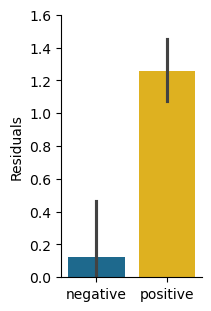

In [57]:
plt.figure(figsize=(2,3), constrained_layout=True)
sns.barplot(x='TauStatus', y='Log2_pTau231_residual', data=subset, hue='TauStatus', palette=[group_colors['neg'], group_colors['pos']])
plt.ylim(0,1.6)
plt.xlabel('')
plt.ylabel('Residuals')
sns.despine()
plt.savefig(os.path.join(figure_path, 'Fig1m_pT231_residuals.png'), dpi=300)
plt.show()